# Pseudodata-based measurement of standard observables

This notebook implements the pseudodata-based closure test for standard kinematic observables using the ATLAS Omnifold Z+jets measurement. Running this measurement and observing good statistical agreement with the target truth pseudodata is a prerequisite for running the data measurement in [`standard_obs_data_results.ipynb`](./standard_obs_data_results.ipynb).

Chi-squared goodness-of-fit tests comparing the OmniFold result to the truth pseudodata target are performed for each observable.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import io
import numpy as np
import uproot
import awkward as ak
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from collections import OrderedDict
from matplotlib.backends.backend_pdf import PdfPages
from common_utils import make_hists_with_uncertainty
from visualize import draw_plot, compare_to_target, figs_to_grid

## Load plotting config

Adjust the file [plot_config.yml](./plot_config.yml) to change what observables are plotting, binning, labels, etc.

In [3]:
with open("plot_config.yml") as f:
    cfg = yaml.safe_load(f)

features = cfg["features"]
features_ylog = cfg["features_ylog"]
ibu_bins = OrderedDict({k: np.asarray(v) for k, v in cfg["bins"].items()})
plot_labels = cfg["plot_labels"]
labels = cfg["labels"]

## Load all data

In [4]:
staging_dir = "/global/cfs/cdirs/m3246/ZjetOmnifold/data/final_public_data"
tree_name = "OmniTree"

truth_mc_path = f"{staging_dir}/truth_mc_events.root"
truth_hv_path = f"{staging_dir}/truth_mc_hv_events.root"
truth_pseudodata_path = f"{staging_dir}/truth_pseudodata_events.root"

In [5]:
# Load event weights for pseudodata measurement
pseudodata_weights = pd.read_hdf(f"{staging_dir}/pseudodata_weights.h5")
pseudodata_hv_weights = pd.read_hdf(f"{staging_dir}/pseudodata_hv_weights.h5")
truth_pseudodata_weights = pd.read_hdf(f"{staging_dir}/truth_pseudodata_weights.h5")

In [6]:
# Load truth-level features from ROOT files (already filtered to truth_pT_ll > 200)
def load_features(path):
    with uproot.open(path) as f:
        t = f[tree_name]
        return {feat: ak.to_numpy(t[f"truth_{feat}"].array()) for feat in features}

mc_features = load_features(truth_mc_path)
hv_features = load_features(truth_hv_path)
pd_features = load_features(truth_pseudodata_path)

## Jet observable selection: minimal hadronic activity requirement

For jet observables (any feature involving `trackj`), we require the corresponding track-jet to have $p_T > 5$ GeV. This ensures a minimal level of hadronic activity in the event and avoids a region where jet reconstruction is unreliable. Lepton and global event observables (`HT_tracks`, `Ntracks`, etc.) are computed from the full event sample without this requirement.

In [7]:
# Split features into lepton and jet observables.
# Jet observables require jet pT > 5 GeV (minimal hadronic activity).
lepton_feature_names = [f for f in features if "trackj" not in f]
jet1_feature_names = [f for f in features if "trackj1" in f]
jet2_feature_names = [f for f in features if "trackj2" in f]

if len(jet1_feature_names) > 0:
    mc_jet1_mask = mc_features["pT_trackj1"] > 5
    hv_jet1_mask = hv_features["pT_trackj1"] > 5
    pd_jet1_mask = pd_features["pT_trackj1"] > 5
if len(jet2_feature_names) > 0:
    mc_jet2_mask = mc_features["pT_trackj2"] > 5
    hv_jet2_mask = hv_features["pT_trackj2"] > 5
    pd_jet2_mask = pd_features["pT_trackj2"] > 5

def _apply_jet_mask(features_dict, mask, feat_names):
    return {f: features_dict[f][mask] for f in feat_names}

def _mask_weights(weights_dict, mask):
    return {k: v[mask] for k, v in weights_dict.items()}

## Prepare vectors of event weights

The nominal measurement and systematic uncertainties are built with vectors of event weights. All of these are loaded into memory here.

In [8]:
# Build weight dictionaries
n_init_weights = [name for name in pseudodata_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_mc_" in name]

pd_weights_dict = {
    "prior": pseudodata_weights["weights_prior"].to_numpy(),
    "nominal": pseudodata_weights["weights_nominal"].to_numpy(),
    **{f"ensemble_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_train_weights)},
    "trackEffMain": pseudodata_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": pseudodata_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": pseudodata_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": pseudodata_weights["weights_trackPtScale"].to_numpy(),
    "muCalID": pseudodata_weights["weights_muCalID"].to_numpy(),
    "muCalMS": pseudodata_weights["weights_muCalMS"].to_numpy(),
    "muCalResBias": pseudodata_weights["weights_muCalResBias"].to_numpy(),
    "muCalScale": pseudodata_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": pseudodata_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": pseudodata_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": pseudodata_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": pseudodata_weights["weights_muEffTrig"].to_numpy(),
    "pileup": pseudodata_weights["weights_pileup"].to_numpy(),
    "lumi": pseudodata_weights["weights_lumi"].to_numpy(),
    "theoryQCD": pseudodata_weights["weights_theoryQCD"].to_numpy(),
    "theoryPDF": pseudodata_weights["weights_theoryPDF"].to_numpy(),
    "theoryAlphaS": pseudodata_weights["weights_theoryAlphaS"].to_numpy(),
    "theoryPSsoft": pseudodata_weights["weights_theoryPSsoft"].to_numpy(),
    "theoryPSjet": pseudodata_weights["weights_theoryPSjet"].to_numpy(),
    "theoryPSscale": pseudodata_weights["weights_theoryPSscale"].to_numpy(),
    "theoryMPI": pseudodata_weights["weights_theoryMPI"].to_numpy(),
    "topBackground": pseudodata_weights["weights_topBackground"].to_numpy(),
    "nonstrongDiboson": pseudodata_weights["weights_nonstrongDiboson"].to_numpy(),
    "nonstrongEW": pseudodata_weights["weights_nonstrongEW"].to_numpy(),
    "dd": pseudodata_weights["weights_dd"].to_numpy(),
    "target_dd": pseudodata_weights["target_dd"].to_numpy(),
    "hvhad": pseudodata_weights["weights_hvhad"].to_numpy(),
}

pd_hv_weights_dict = {
    "nominal": pseudodata_hv_weights["weights_hv"].to_numpy(),
}

truth_pd_weights_dict = {
    "nominal": truth_pseudodata_weights["weights_nominal"].to_numpy(),
}

In [9]:
# Compute measurement histograms (MC reweighted to pseudodata + HV uncertainty).
# Jet observables use only events with subleading jet pT > 5 GeV.
omni_features_results = {
    **(make_hists_with_uncertainty(
        data=mc_features, bins=ibu_bins, observables=lepton_feature_names,
        weights_dict=pd_weights_dict,
    ) if len(lepton_feature_names) > 0 else {}),
    **(make_hists_with_uncertainty(
        data=_apply_jet_mask(mc_features, mc_jet1_mask, jet1_feature_names),
        bins=ibu_bins, observables=jet1_feature_names,
        weights_dict=_mask_weights(pd_weights_dict, mc_jet1_mask),
    ) if len(jet1_feature_names) > 0 else {}),
    **(make_hists_with_uncertainty(
        data=_apply_jet_mask(mc_features, mc_jet2_mask, jet2_feature_names),
        bins=ibu_bins, observables=jet2_feature_names,
        weights_dict=_mask_weights(pd_weights_dict, mc_jet2_mask),
    ) if len(jet2_feature_names) > 0 else {}),
}
hv_features_results = {
    **(make_hists_with_uncertainty(
        data=hv_features, bins=ibu_bins, observables=lepton_feature_names,
        weights_dict=pd_hv_weights_dict,
    ) if len(lepton_feature_names) > 0 else {}),
    **(make_hists_with_uncertainty(
        data=_apply_jet_mask(hv_features, hv_jet1_mask, jet1_feature_names),
        bins=ibu_bins, observables=jet1_feature_names,
        weights_dict=_mask_weights(pd_hv_weights_dict, hv_jet1_mask),
    ) if len(jet1_feature_names) > 0 else {}),
    **(make_hists_with_uncertainty(
        data=_apply_jet_mask(hv_features, hv_jet2_mask, jet2_feature_names),
        bins=ibu_bins, observables=jet2_feature_names,
        weights_dict=_mask_weights(pd_hv_weights_dict, hv_jet2_mask),
    ) if len(jet2_feature_names) > 0 else {}),
}
for obs in features:
    omni_features_results[obs]["hv"] = hv_features_results[obs]["nominal"]

# Compute truth pseudodata histograms (target for the closure test)
truth_pd_features_results = {
    **(make_hists_with_uncertainty(
        data=pd_features, bins=ibu_bins, observables=lepton_feature_names,
        weights_dict=truth_pd_weights_dict,
    ) if len(lepton_feature_names) > 0 else {}),
    **(make_hists_with_uncertainty(
        data=_apply_jet_mask(pd_features, pd_jet1_mask, jet1_feature_names),
        bins=ibu_bins, observables=jet1_feature_names,
        weights_dict=_mask_weights(truth_pd_weights_dict, pd_jet1_mask),
    ) if len(jet1_feature_names) > 0 else {}),
    **(make_hists_with_uncertainty(
        data=_apply_jet_mask(pd_features, pd_jet2_mask, jet2_feature_names),
        bins=ibu_bins, observables=jet2_feature_names,
        weights_dict=_mask_weights(truth_pd_weights_dict, pd_jet2_mask),
    ) if len(jet2_feature_names) > 0 else {}),
}

## IBU results

In [10]:
# from common_utils import json_to_hist

# # TODO: update these paths when IBU JSON files are available on NERSC
# ibu_pd_jet_obs = "/path/to/IBU_pseudodata_pass200andSideBin_jetVars.json"
# ibu_pd_nom_obs = "/path/to/IBU_pseudodata_pass200andSideBin_nomVars.json"

# nom_vars = {"pT_l1", "pT_l2", "eta_l1", "eta_l2", "phi_l1", "phi_l2", "pT_ll", "y_ll"}
# ibu_results = {
#     feature: json_to_hist(
#         ibu_pd_nom_obs if feature in nom_vars else ibu_pd_jet_obs,
#         bins=ibu_bins[feature],
#         var=feature,
#     )
#     for feature in features
# }

## Reweighting check

Visualize the reweighting of MadGraph+Pythia8 MC to match truth pseudodata for a quick sanity check before running the full uncertainty plots.

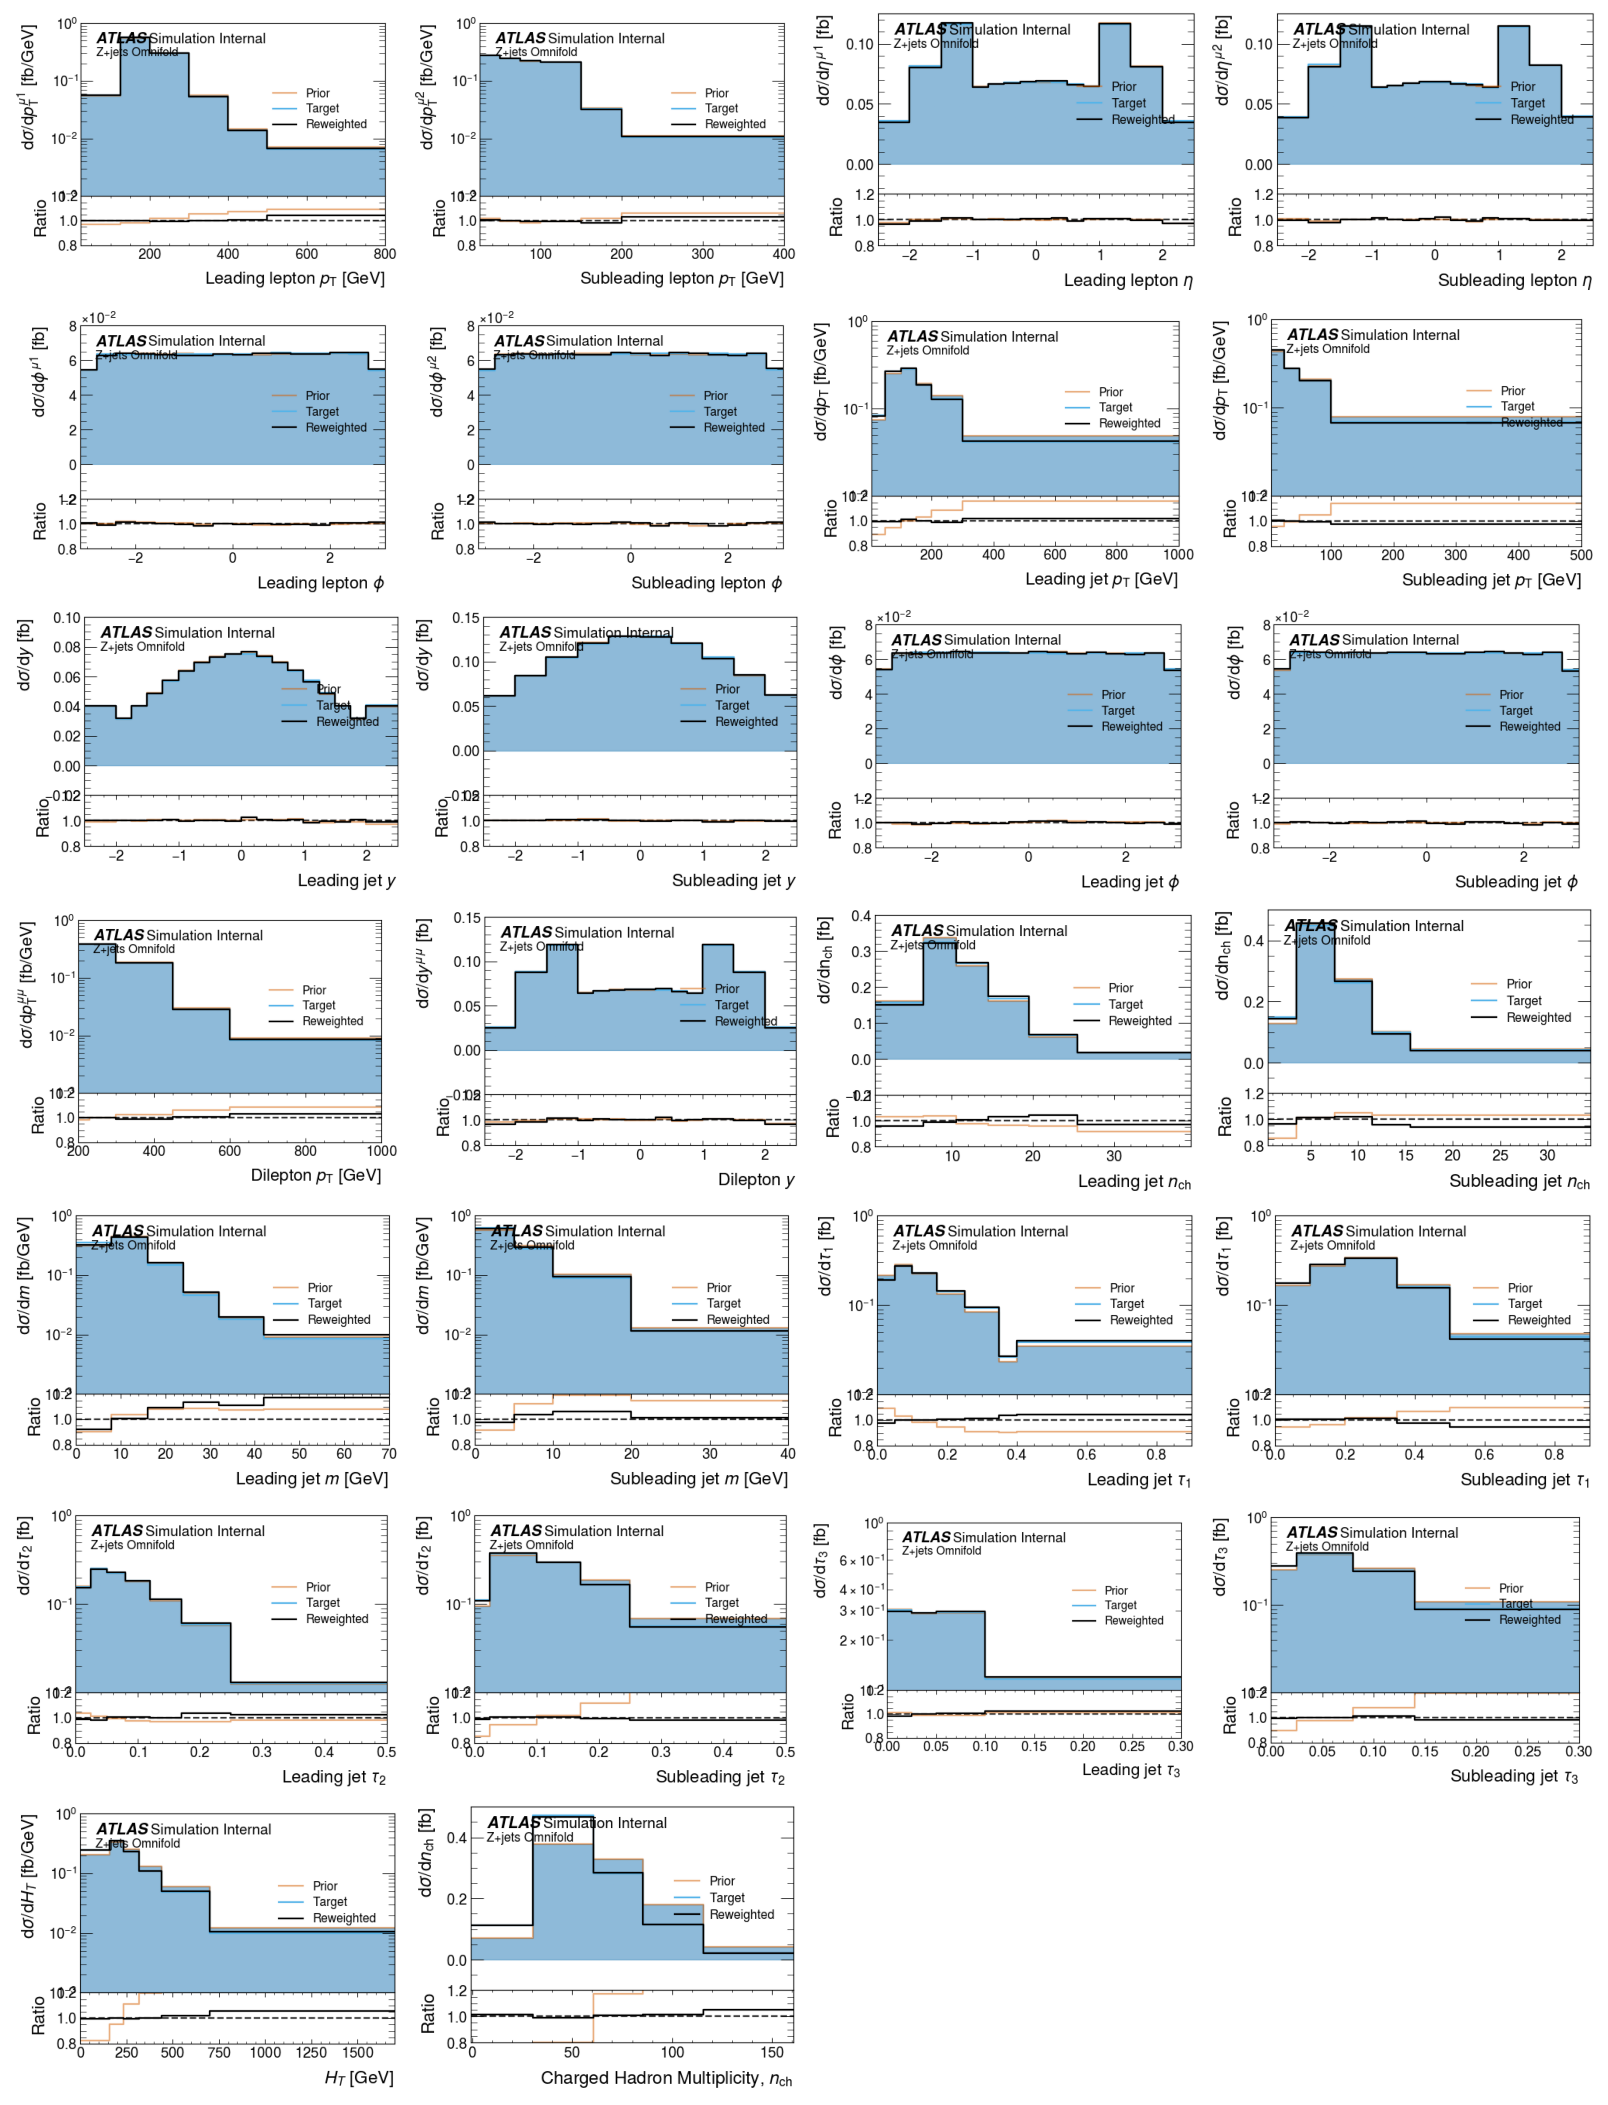

In [11]:
os.makedirs("plots/pd", exist_ok=True)

reweighting_figs = []

for feature in features:
    fig = compare_to_target(
        omni_features_results[feature],
        truth_pd_features_results[feature],
        target_key="nominal",
        log_xscale=False,
        linear_yscale=not features_ylog[feature],
        ylabel=labels[feature],
        xlabel=plot_labels[feature],
        normalize=True,
    )
    fig.savefig(f"plots/pd/{feature}_reweighting.pdf", dpi=300, bbox_inches="tight")
    reweighting_figs.append(fig)
    plt.close(fig)

grid_reweighting = figs_to_grid(reweighting_figs, ncols=4)
grid_reweighting.show()

## Plotting with full uncertainties and chi-squared tests

Individual per-feature PDFs are saved to `plots/pd/<feature>.pdf`. Grid overviews are saved to `plots/pd/all_xsec_grid.pdf` and `plots/pd/all_budget_grid.pdf`.
Note that a Gaussian kernel smoothing is by default applied to all observables except the track-jet masses.
See the usage recommendations for more details.

In [12]:
xsec_figs = []
budget_figs = []

for feature in features:
    fig, fig_budget, fig_cov = draw_plot(
        omni_results=omni_features_results[feature],
        # ibu_results=ibu_results[feature],
        binning=ibu_bins[feature],
        ylabel=labels[feature],
        xlabel=plot_labels[feature],
        draw_uncertainty_budget=True,
        is_xSec=True,
        is_omni_data=False,
        ratio_ylim=[0.8, 1.2],
        logyScale=features_ylog[feature],
        results_list=[truth_pd_features_results[feature]],
        formatting_dicts=[
            {
                "color": "red",
                "label": "Truth pseudodata",
                "marker": "o",
                "is_omni_data": False,
                "is_truth_pd": True,
            }
        ],
        do_chi2_test=True,
        pdf_name=f"plots/pd/{feature}.pdf",
        smooth_hv=False if feature in ["m_trackj1", "m_trackj2"] else True,
    )
    xsec_figs.append(fig)
    if fig_budget is not None:
        budget_figs.append(fig_budget)
    plt.close(fig)
    if fig_budget is not None:
        plt.close(fig_budget)
    if fig_cov is not None:
        plt.close(fig_cov)


Chi-squared test: dof=6, χ²=4.57204, p-value=0.5997
Chi-squared test: dof=6, χ²=8.19891, p-value=0.2239
Chi-squared test: dof=14, χ²=11.10533, p-value=0.6777
Chi-squared test: dof=14, χ²=4.33683, p-value=0.9931
Chi-squared test: dof=16, χ²=13.52491, p-value=0.6341
Chi-squared test: dof=16, χ²=17.33786, p-value=0.3641
Chi-squared test: dof=6, χ²=11.27349, p-value=0.0803
Chi-squared test: dof=4, χ²=2.12111, p-value=0.7135
Chi-squared test: dof=18, χ²=14.02845, p-value=0.7272
Chi-squared test: dof=10, χ²=5.68827, p-value=0.8407
Chi-squared test: dof=16, χ²=7.01758, p-value=0.9729
Chi-squared test: dof=16, χ²=7.77038, p-value=0.9554
Chi-squared test: dof=5, χ²=4.42028, p-value=0.4906
Chi-squared test: dof=14, χ²=15.66082, p-value=0.3345
Chi-squared test: dof=6, χ²=10.37838, p-value=0.1096
Chi-squared test: dof=5, χ²=4.72453, p-value=0.4504
Chi-squared test: dof=6, χ²=15.55839, p-value=0.0163
Chi-squared test: dof=4, χ²=9.22917, p-value=0.0556
Chi-squared test: dof=7, χ²=3.32176, p-value=0.

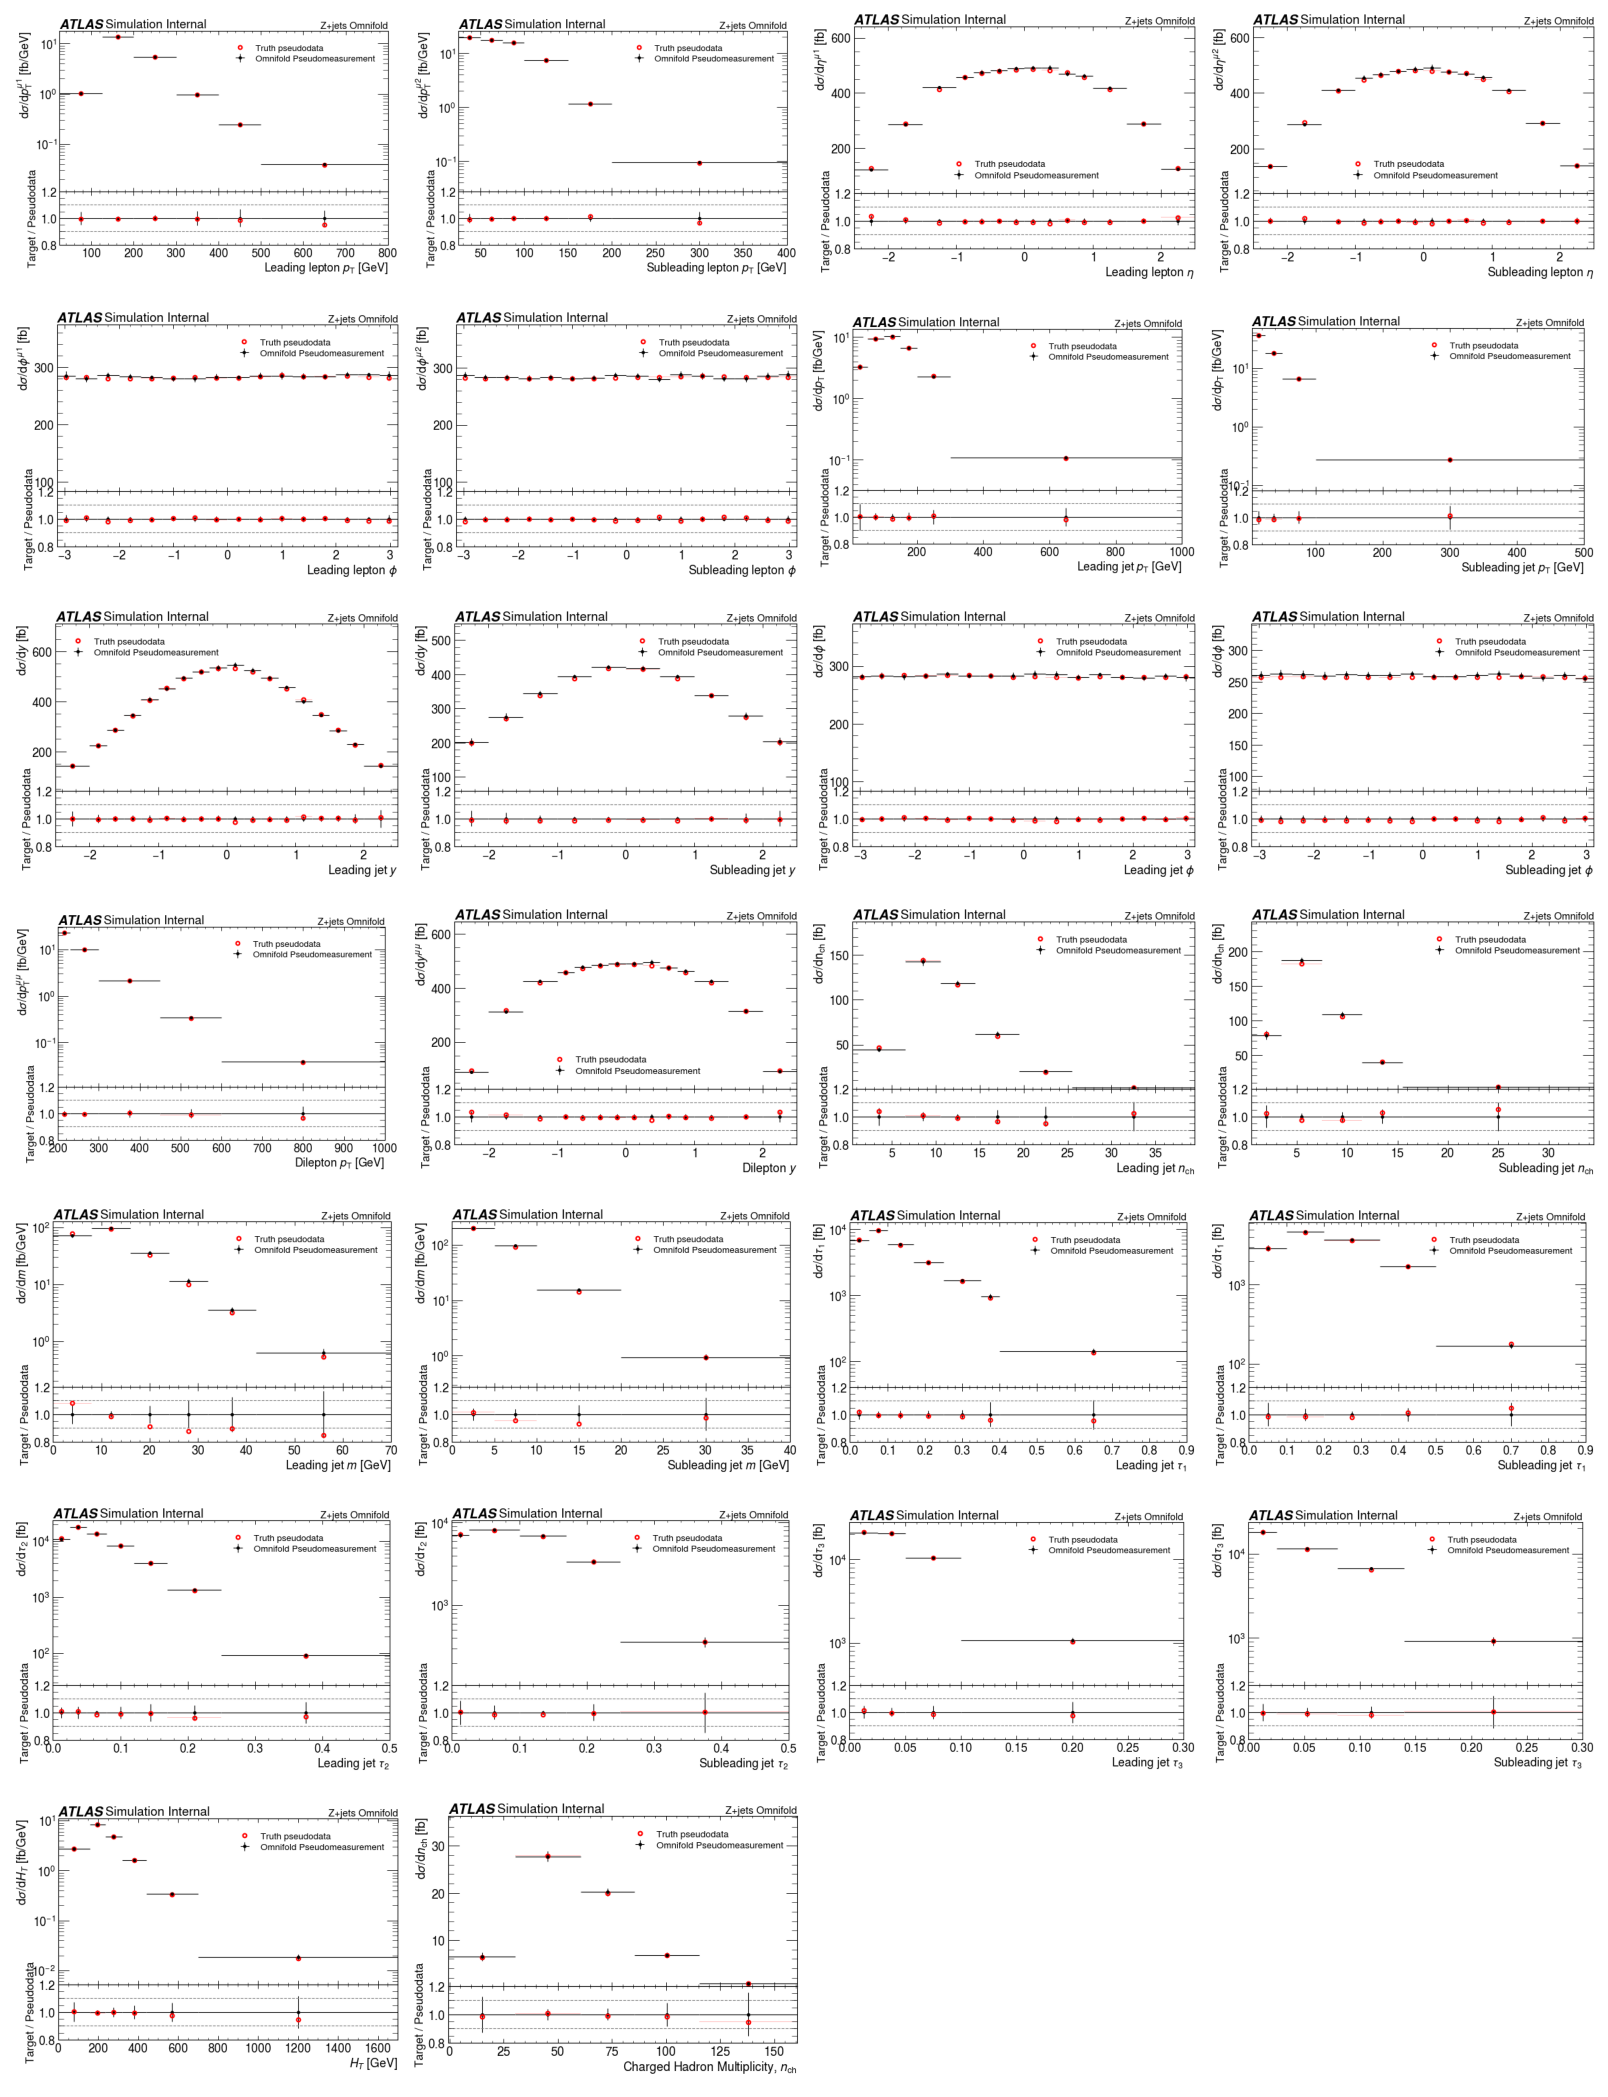

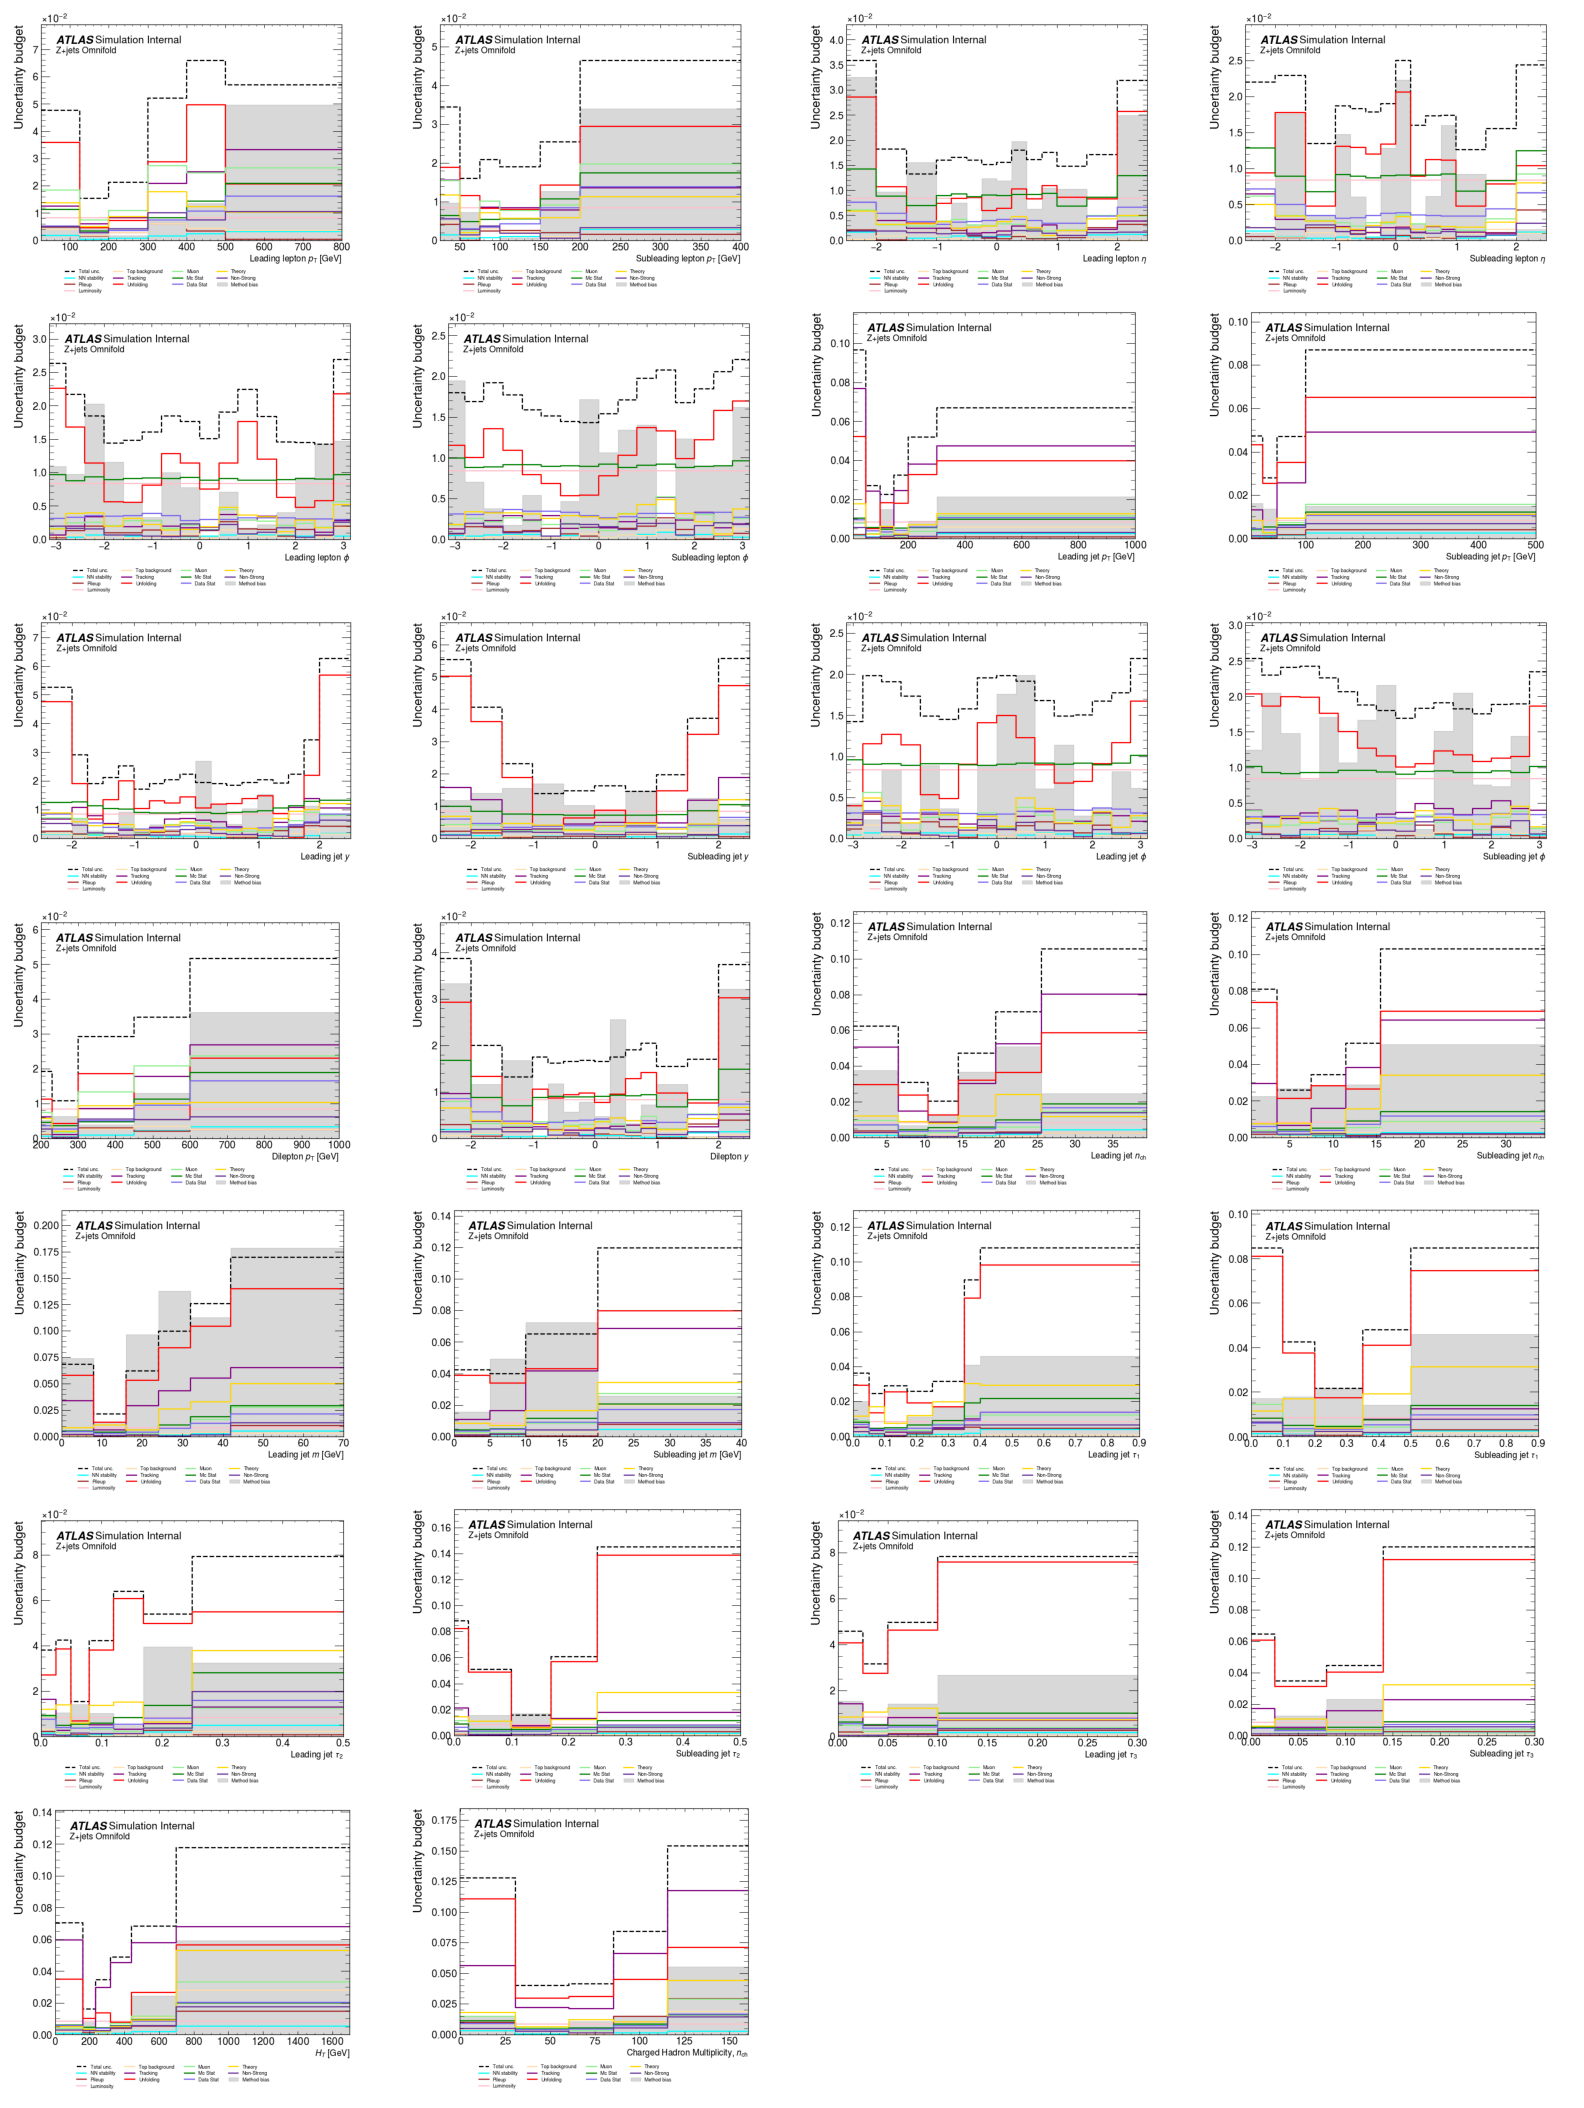

In [13]:
grid_xsec = figs_to_grid(xsec_figs, ncols=4)
grid_budget = figs_to_grid(budget_figs, ncols=4)

with PdfPages("plots/pd/all_xsec_grid.pdf") as pdf:
    pdf.savefig(grid_xsec, bbox_inches="tight")
with PdfPages("plots/pd/all_budget_grid.pdf") as pdf:
    pdf.savefig(grid_budget, bbox_inches="tight")

grid_xsec.show()
grid_budget.show()